# <div align="center">Análisis de juegos de mesa</div>
### <div align="center">v1.0.0</div>

# Introducción

Los **juegos de mesa** han evolucionado hacia propuestas cada vez más complejas y diseños más originales. En los últimos años, se ha generado una gran cantidad de datos relacionados con estos juegos gracias a plataformas como **BoardGameGeek (BGG)**, considerada una de las mayores bases de datos sobre juegos de mesa a nivel mundial. En esta plataforma, además de recopilar información acerca de los juegos, los usuarios pueden **valorarlos y comentarlos**, lo que permite la **creación de rankings** tanto globales como por tipo de juego.

Este trabajo se basa en dicha fuente de información, accesible para usuarios registrados, desde la cual es posible obtener conjuntos de datos para su posterior análisis. El enlace es el siguiente: **[Database_BoardGameGeek](https://boardgamegeek.com/data_dumps/bg_ranks)**

El objetivo de este trabajo es analizar la evolución de los juegos de mesa, así como comparar los diferentes tipos de juegos en función de sus rankings y valoraciones, con el fin de obtener una visión clara sobre el posible futuro de esta afición.

# Análisis de los datos

## Pasos Previos

En primer lugar hace falta instalar la librería de pymongo, así como importar MongoClient de dicha librería. 

In [2]:
#!pip install pymongo
from pymongo import MongoClient
import matplotlib.pyplot as plt
import pandas as pd

Para conectar el entorno de Jupyter Notebook con la base de datos gestionada en MongoDB Compass, es necesario utilizar el cliente MongoClient previamente importado, indicando la dirección del servidor (localhost) y el puerto correspondiente.

In [3]:
mongoClient = MongoClient("localhost", 27017)
db = mongoClient.Bgg
collection = db.BoardGameGeek

Una vez realizados estos pasos, ya se puede sustraer información del database y analizar su contenido.

## Exploración y consulta de datos

En primer lugar, es relevante conocer el volumen de juegos que compone nuestro dataset. Para ello, realizamos la siguiente consulta:

In [4]:
print(collection.count_documents({}))

175196


También es necesario saber el nombre de las columnas que tiene este dataset:

In [20]:
list(collection.find_one().keys())

['_id',
 'id',
 'name',
 'yearpublished',
 'rank',
 'bayesaverage',
 'average',
 'usersrated',
 'is_expansion',
 'abstracts_rank',
 'cgs_rank',
 'childrensgames_rank',
 'familygames_rank',
 'partygames_rank',
 'strategygames_rank',
 'thematic_rank',
 'wargames_rank']

### Análisis de número de juegos de mesa por año

Para empezar con el análisis evolutivo, es importante agrupar los juegos por año y observar como ha ido creciendo la aficción. Para ello se utiliza la función aggregate para lograrlo

In [5]:
pipeline = [
    {
        "$match": {"yearpublished": {"$ne": None}}
    },
    {
        "$group": {
            "_id": "$yearpublished",
            "total_juegos": {"$sum": 1}
        }
    },
    {
        "$sort": {"_id": 1}
    }
]

result = list(collection.aggregate(pipeline))

df_juegos_anno = pd.DataFrame(result).rename(columns={"_id": "Año", "total_juegos": "Total juegos"})
df_juegos_anno

,Año,Total juegos
0,-3500,1
1,-3000,5
2,-2600,2
3,-2200,1
4,-2000,2
...,...,...
338,2026,3230
339,2027,249
340,2028,13
341,2030,1


Como se observa en el dataset, **existen juegos con años de publicación muy antiguos**, así como títulos que aún no han salido al mercado (por ejemplo, el **registrado en 2099**, que probablemente se trate de un **error** en la base de datos). Para **las visualizaciones**, se considerará el **rango 1900-2025**, ya que es el intervalo donde se concentra la mayor parte de los juegos.

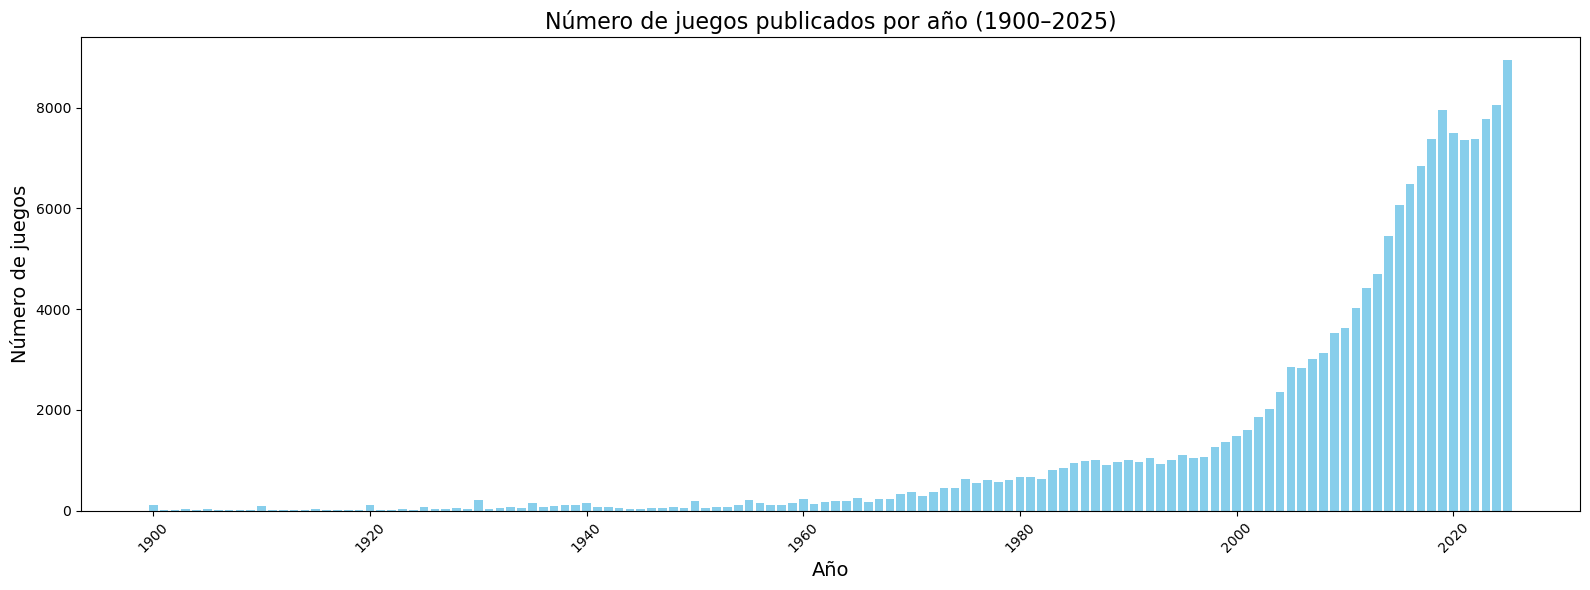

In [6]:
df_plot_años = df_juegos_anno[(df_juegos_anno["Año"] >= 1900) & (df_juegos_anno["Año"] <= 2025)]
plt.figure(figsize=(16,6))
plt.bar(df_plot_años["Año"], df_plot_años["Total juegos"], color="skyblue")
plt.title("Número de juegos publicados por año (1900–2025)", fontsize=16)
plt.xlabel("Año", fontsize=14)
plt.ylabel("Número de juegos", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se ha podido observar cómo la **publicación de juegos de mesa** ha ido **creciendo** en los últimos años a un ritmo **casi exponencial**, con una caida en torno a 2020 probablemente producida por la pandemia. La pregunta que surge tras este análisis es si **cantidad implica calidad**. Por ello, **se quiere estudiar si el top global de juegos de mesa también ha crecido de forma proporcional**, es decir, si los juegos más recientes han logrado introducirse en el ranking global o si, por el contrario, este sigue estando dominado por títulos publicados hace varios años.

### Análisis de la evolución del Ranking General

In [7]:
pipeline = [
    {
        "$match": {
            "rank": {"$gte": 1, "$lte": 1000} 
        }
    },
    {
        "$group": {
            "_id": "$yearpublished",
            "top_juegos": {"$sum": 1}
        }
    },
    {
        "$sort": {"_id": 1}
    }
]
result_top = list(collection.aggregate(pipeline))
df_rank_por_anno = pd.DataFrame(result_top).rename(columns={"_id": "Año", "top_juegos": "Top juegos en ranking"})
df_rank_por_anno

,Año,Top juegos en ranking
0,-2200,1
1,1475,1
2,1630,1
3,1800,1
4,1876,1
5,1959,1
6,1963,1
7,1979,1
8,1980,2
9,1981,1


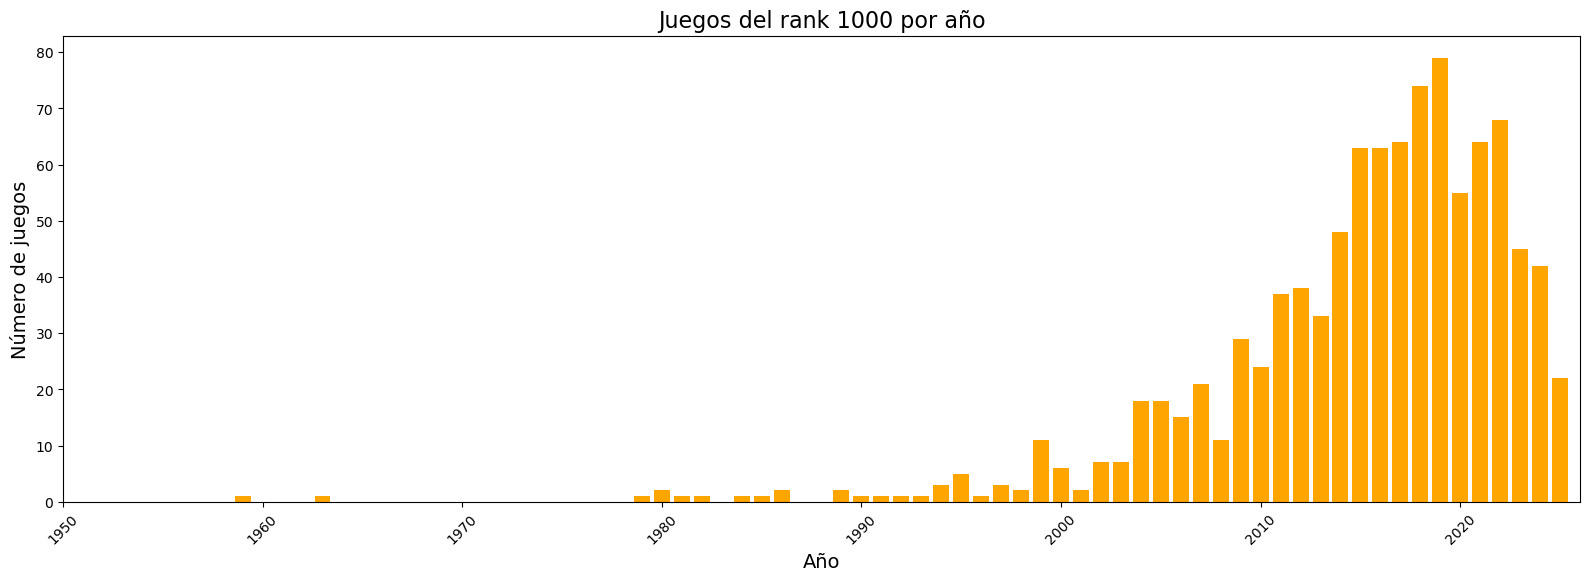

In [8]:
años = [r["_id"] for r in result_top]
top_juegos = [r["top_juegos"] for r in result_top]
plt.figure(figsize=(16,6))
plt.bar(años, top_juegos, color='orange')
plt.title("Juegos del rank 1000 por año", fontsize=16)
plt.xlabel("Año", fontsize=14)
plt.ylabel("Número de juegos", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlim(1950, 2026)
plt.show()

Se puede observar cómo la **calidad de los juegos de mesa** ha ido **aumentando de forma paralela a la cantidad**. Si bien para los años más recientes el número de juegos presentes en el ranking es inferior al del pico máximo, cabe considerar **diversos factores** que pueden explicar este descenso, como el hecho de que **muchos títulos recientes aún no hayan acumulado un volumen suficiente de valoraciones** por parte de los usuarios. **En términos generales**, se puede concluir que, a pesar del notable incremento en la cantidad de juegos publicados, **la calidad no se ha visto comprometida a lo largo del tiempo**, y los nuevos títulos continúan incorporándose con normalidad al ranking global.

### Análisis por categorías

Una vez analizada la relación entre cantidad y calidad de forma general, **el siguiente paso** consiste en profundizar en el **análisis por categorías**. Para ello, se estudiará **qué tipo de juego es el más popular, el más publicado y el de mayor calidad**, tomando como referencia los **rankings temáticos de BGG**. Como punto de partida, **se analiza cuántos juegos del top global se encuentran presentes en cada uno de los rankings por categoría**, lo que permitirá identificar qué géneros tienen una mayor representación en el ranking global y, por tanto, cuáles gozan de mayor reconocimiento entre la comunidad de jugadores.

In [9]:
pipeline = [
    {
        "$match": {
            "rank": {"$gte": 1, "$lte": 1000}
        }
    },
    {
        "$group": {
            "_id": None,
            "abstracts": {"$sum": {"$cond": [{"$ne": ["$abstracts_rank", None]}, 1, 0]}},
            "cgs": {"$sum": {"$cond": [{"$ne": ["$cgs_rank", None]}, 1, 0]}},
            "childrensgames": {"$sum": {"$cond": [{"$ne": ["$childrensgames_rank", None]}, 1, 0]}},
            "familygames": {"$sum": {"$cond": [{"$ne": ["$familygames_rank", None]}, 1, 0]}},
            "partygames": {"$sum": {"$cond": [{"$ne": ["$partygames_rank", None]}, 1, 0]}},
            "strategygames": {"$sum": {"$cond": [{"$ne": ["$strategygames_rank", None]}, 1, 0]}},
            "thematic": {"$sum": {"$cond": [{"$ne": ["$thematic_rank", None]}, 1, 0]}},
            "wargames": {"$sum": {"$cond": [{"$ne": ["$wargames_rank", None]}, 1, 0]}}
        }
    }
]

result_rankings = list(collection.aggregate(pipeline))
df_rankings = pd.DataFrame([result_rankings[0]]).drop(columns=["_id"]).T
df_rankings.columns = ["Total juegos en ranking"]
df_rankings.index.name = "Ranking"
df_rankings.sort_values("Total juegos en ranking", ascending=False)

,Total juegos en ranking
Ranking,
strategygames,584
familygames,273
thematic,199
partygames,54
wargames,54
abstracts,34
cgs,23
childrensgames,2


In [10]:
total = df_rankings["Total juegos en ranking"].sum()
print(f"Suma total de juegos en rankings de categoría: {total}")

Suma total de juegos en rankings de categoría: 1223


Cabe destacar que la **suma de los resultados es superior a 1000**, dado que existen **223 juegos presentes en más de un ranking** de categoría simultáneamente, por lo que **han sido contabilizados más de una vez**.

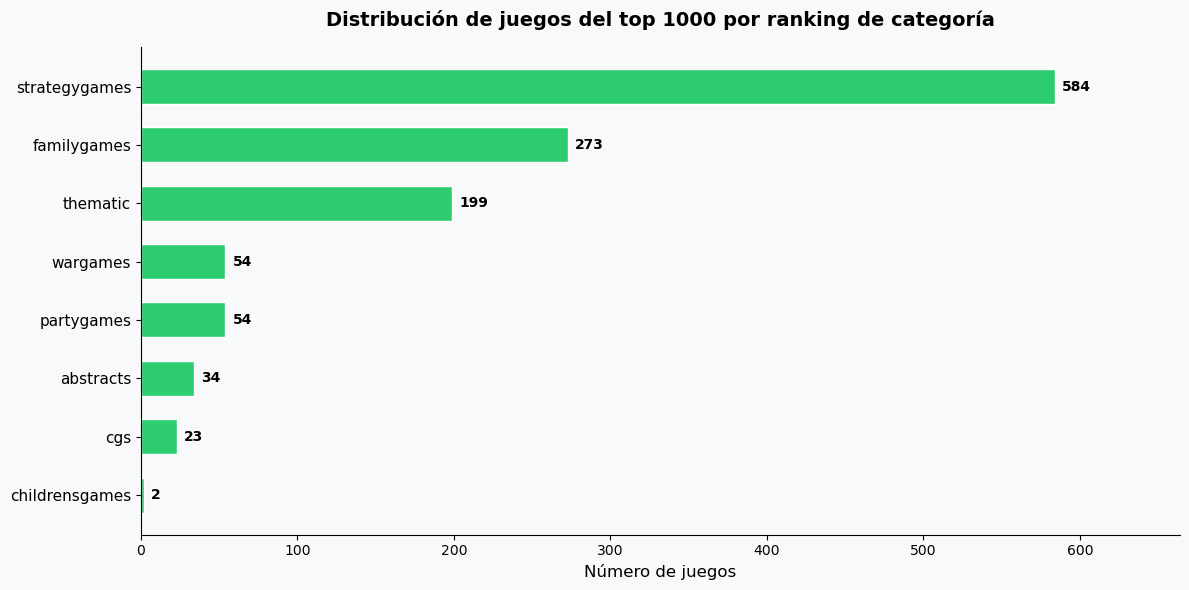

In [11]:
df_plot = df_rankings.sort_values("Total juegos en ranking", ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

colores = ["#2ecc71" if v < 1000 else "#e74c3c" for v in df_plot["Total juegos en ranking"]]
bars = ax.barh(df_plot.index, df_plot["Total juegos en ranking"], color=colores, edgecolor="white", height=0.6)

ax.bar_label(bars, padding=5, fontsize=10, fontweight="bold")

ax.set_xlabel("Número de juegos", fontsize=12)
ax.set_title("Distribución de juegos del top 1000 por ranking de categoría", fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, df_plot["Total juegos en ranking"].max() + 80)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=11)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.show()

Como se puede observar en el gráfico, los **juegos de estrategia** dominan ampliamente el ranking global, seguidos de los **juegos familiares y los temáticos**. Las demás categorías tienen una presencia significativamente menor. Podemos incluso mostrar **aquellos juegos del ranking que tengan un bayesaverage mayor a 8 y que sean estratégicos**:

In [13]:
result = list(collection.find(
    {"$and": [
        {"rank": {"$lte": 1000}},
        {"strategygames_rank": {"$ne": None}},
        {"bayesaverage": {"$gt": 8}}
    ]},
    {"_id": 0, "name": 1, "rank": 1, "strategygames_rank": 1, "bayesaverage": 1}
))
pd.DataFrame(result)

,name,rank,bayesaverage,strategygames_rank
0,Brass: Birmingham,1,8.39467,1
1,Ark Nova,2,8.35512,2
2,Pandemic Legacy: Season 1,3,8.34778,3
3,Gloomhaven,4,8.30205,5
4,Dune: Imperium – Uprising,5,8.22586,4
5,Dune: Imperium,6,8.22357,7
6,Twilight Imperium: Fourth Edition,7,8.21918,6
7,Terraforming Mars,9,8.18850,8
8,Spirit Island,11,8.14200,10
9,Gloomhaven: Jaws of the Lion,12,8.10060,12


### Análisis de la evolución del rating promedio por año

A continuación se analiza la **evolución del rating promedio por año de publicación**, con el objetivo de determinar si **los juegos modernos están mejor valorados que los clásicos** o si, por el contrario, existen épocas concretas que destacan por encima del resto. Para ello **se utiliza el bayesaverage**, que al **incorporar un factor de corrección basado en el número de valoraciones**, ofrece una medida más fiable y comparable entre juegos de distintas épocas.

In [13]:
pipeline_rating_anno = [
    {
        "$match": {
            "yearpublished": {"$gte": 1900, "$lte": 2025},
            "bayesaverage": {"$gt": 0}
        }
    },
    {
        "$group": {
            "_id": "$yearpublished",
            "rating_promedio": {"$avg": "$bayesaverage"},
            "total_juegos": {"$sum": 1}
        }
    },
    {"$sort": {"_id": 1}}
]

result_rating_anno = list(collection.aggregate(pipeline_rating_anno))
df_rating_anno = pd.DataFrame(result_rating_anno).rename(columns={"_id": "Año", "rating_promedio": "Rating promedio", "total_juegos": "Total juegos"})
df_rating_anno

,Año,Rating promedio,Total juegos
0,1900,5.396255,4
1,1903,5.662908,4
2,1904,5.798450,1
3,1906,5.739020,2
4,1908,5.492920,1
...,...,...,...
108,2021,5.710153,2065
109,2022,5.704618,2129
110,2023,5.688283,2076
111,2024,5.676889,1855


Se puede realizar además una **consulta para saber el año con el rating promedio mayor**, teniendo en cuenta solo aquellos **años con más de 50 juegos publicados**.

In [14]:
pipeline_mejor_anno = [
    {
        "$match": {
            "yearpublished": {"$gte": 1900, "$lte": 2025},
            "bayesaverage": {"$gt": 0}
        }
    },
    {
        "$group": {
            "_id": "$yearpublished",
            "rating_promedio": {"$avg": "$bayesaverage"},
            "total_juegos": {"$sum": 1}
        }
    },
    {
        "$match": {
            "total_juegos": {"$gte": 50}
        }
    },
    {"$sort": {"rating_promedio": -1}},
    {"$limit": 3}
]

result_mejor_anno = list(collection.aggregate(pipeline_mejor_anno))
df_mejor_anno = pd.DataFrame(result_mejor_anno).rename(columns={"_id": "Año", "rating_promedio": "Rating promedio", "total_juegos": "Total juegos"})
df_mejor_anno

,Año,Rating promedio,Total juegos
0,2021,5.710153,2065
1,2020,5.708087,2087
2,2017,5.707258,2417


Como resultado, el **año con mayor rating promedio es 2021**, si bien la **diferencia** con el segundo y tercer año **es mínima**. Esto **sugiere una evolución sostenida** en la calidad de los juegos publicados, cuyos **ratings se mantienen estables** de un año a otro sin variaciones significativas.


Cabe matizar que este **análisis es independiente del realizado anteriormente sobre el ranking global**. El hecho de que el número de juegos presentes en el ranking haya crecido a lo largo del tiempo no implica necesariamente que el rating promedio deba seguir la misma tendencia, ya que ambas métricas miden aspectos distintos: **una refleja la cantidad de juegos reconocidos por la comunidad, mientras que la otra mide la valoración media que reciben**.

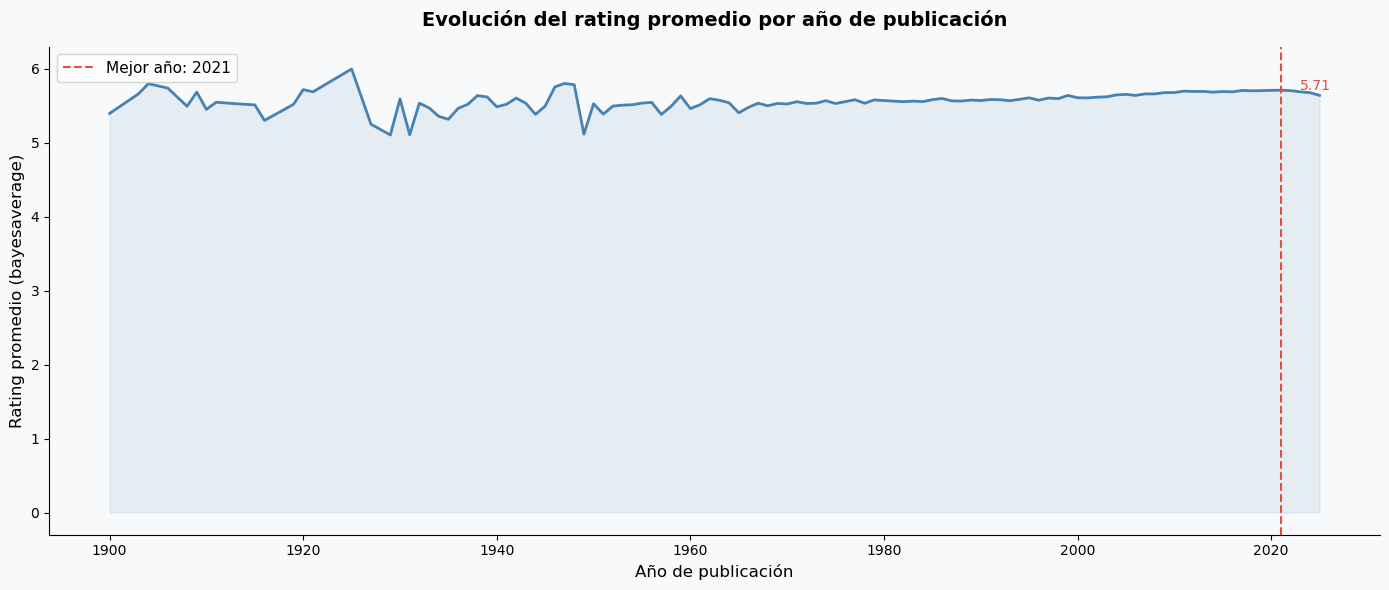

In [15]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_rating_anno["Año"], df_rating_anno["Rating promedio"], color="steelblue", linewidth=2)
ax.fill_between(df_rating_anno["Año"], df_rating_anno["Rating promedio"], alpha=0.1, color="steelblue")

mejor_anno = df_mejor_anno["Año"].values[0]
mejor_rating = df_mejor_anno["Rating promedio"].values[0]
ax.axvline(x=mejor_anno, color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Mejor año: {mejor_anno}")
ax.annotate(f"{mejor_rating:.2f}", xy=(mejor_anno, mejor_rating), xytext=(mejor_anno + 2, mejor_rating),
            fontsize=10, color="#e74c3c")

ax.set_xlabel("Año de publicación", fontsize=12)
ax.set_ylabel("Rating promedio (bayesaverage)", fontsize=12)
ax.set_title("Evolución del rating promedio por año de publicación", fontsize=14, fontweight="bold", pad=15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Análisis de Distribución de Ratings

A continuación se analiza la **distribución de los ratings de los juegos del dataset**, con el objetivo de determinar **cómo de exigentes son los usuarios de BGG** a la hora de valorar los juegos. Para ello se estudiarán **cuántos juegos superan distintos umbrales de valoración**, lo que permitirá hacerse una idea del nivel de calidad general percibido por la comunidad.

In [28]:
pipeline_umbrales = [
    {
        "$match": {
            "bayesaverage": {"$gt": 0}
        }
    },
    {
        "$group": {
            "_id": None,
            "sobre_7": {"$sum": {"$cond": [{"$gte": ["$bayesaverage", 7]}, 1, 0]}},
            "sobre_8": {"$sum": {"$cond": [{"$gte": ["$bayesaverage", 8]}, 1, 0]}},
            "sobre_9": {"$sum": {"$cond": [{"$gte": ["$bayesaverage", 9]}, 1, 0]}}
        }
    }
]

result_umbrales = list(collection.aggregate(pipeline_umbrales))
df_umbrales = pd.DataFrame([result_umbrales[0]]).drop(columns=["_id"]).T
df_umbrales.columns = ["Total juegos"]
df_umbrales.index.name = "Umbral"
df_umbrales

,Total juegos
Umbral,
sobre_7,603
sobre_8,26
sobre_9,0


Los resultados muestran que la **comunidad de BGG es bastante exigente en sus valoraciones**. De todos los juegos del dataset con valoraciones registradas, únicamente **603 superan el umbral de 7**, cifra que se reduce drásticamente a **26 juegos por encima de 8**, y **ninguno alcanza el 9**. Esto refleja el efecto del bayesaverage, que al incorporar un factor de corrección penaliza las valoraciones extremas y hace que las puntuaciones altas sean especialmente difíciles de alcanzar, lo que convierte a los **juegos mejor valorados en títulos verdaderamente excepcionales dentro de la comunidad**.

Si **no se tuviese en cuenta el efecto del bayesaverage**, podrían aparecer **juegos** con **muy pocas valoraciones pero de puntuación muy alta**, lo que distorsionaría los resultados. De hecho, estos juegos **ni siquiera se encontrarían en el top 100**, precisamente porque BGG ya aplica este factor de corrección para evitar dicho efecto a la hora de construir el ranking.

In [18]:
result = list(collection.find(
    {"$or": [
        {"rank": {"$lte": 100}},
        {"average": {"$gt": 7.5}}
    ],
    "rank": {"$gte": 1}},
    {"_id": 0, "name": 1, "rank": 1, "average": 1}
))
pd.DataFrame(result)

,name,rank,average
0,Brass: Birmingham,1,8.56680
1,Ark Nova,2,8.54206
2,Pandemic Legacy: Season 1,3,8.50417
3,Gloomhaven,4,8.54313
4,Dune: Imperium – Uprising,5,8.70474
...,...,...,...
3802,Mischief & Malice TCG,26314,9.12821
3803,Demon Espionage,26457,7.81818
3804,Hungry Little Demons,26756,7.84375
3805,Frontier: The Card Game,27320,7.92500


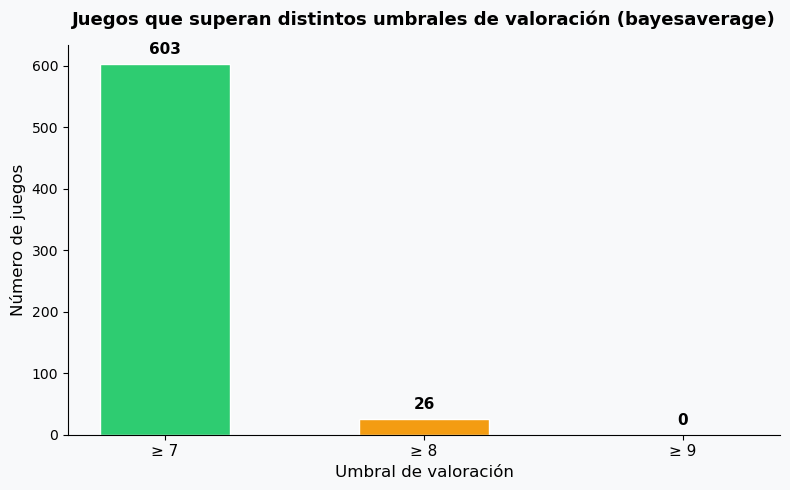

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

colores = ["#2ecc71", "#f39c12", "#e74c3c"]
bars = ax.bar(df_umbrales.index, df_umbrales["Total juegos"], color=colores, edgecolor="white", width=0.5)

ax.bar_label(bars, padding=5, fontsize=11, fontweight="bold")
ax.set_xlabel("Umbral de valoración", fontsize=12)
ax.set_ylabel("Número de juegos", fontsize=12)
ax.set_title("Juegos que superan distintos umbrales de valoración (bayesaverage)", fontsize=13, fontweight="bold", pad=15)
ax.set_xticks(range(len(df_umbrales.index)))
ax.set_xticklabels(["≥ 7", "≥ 8", "≥ 9"], fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

plt.tight_layout()
plt.show()

A continuación se **compara el rating promedio de los juegos presentes únicamente en el ranking global frente a aquellos que aparecen simultáneamente en varios rankings de categoría**. El objetivo es determinar **si los juegos más versátiles**, es decir, los que encajan en múltiples categorías, **tienden a estar mejor valorados por la comunidad**.

In [33]:
pipeline_comparativa = [
    {
        "$match": {
            "rank": {"$gte": 1, "$lte": 1000},
            "bayesaverage": {"$gt": 0}
        }
    },
    {
        "$project": {
            "bayesaverage": 1,
            "total_rankings": {
                "$add": [
                    {"$cond": [{"$ne": ["$abstracts_rank", None]}, 1, 0]},
                    {"$cond": [{"$ne": ["$cgs_rank", None]}, 1, 0]},
                    {"$cond": [{"$ne": ["$childrensgames_rank", None]}, 1, 0]},
                    {"$cond": [{"$ne": ["$familygames_rank", None]}, 1, 0]},
                    {"$cond": [{"$ne": ["$partygames_rank", None]}, 1, 0]},
                    {"$cond": [{"$ne": ["$strategygames_rank", None]}, 1, 0]},
                    {"$cond": [{"$ne": ["$thematic_rank", None]}, 1, 0]},
                    {"$cond": [{"$ne": ["$wargames_rank", None]}, 1, 0]}
                ]
            }
        }
    },
    {
        "$group": {
            "_id": {"$cond": [{"$gte": ["$total_rankings", 2]}, "Dos o más categorías", "Una categoría"]},
            "rating_promedio": {"$avg": "$bayesaverage"},
            "total_juegos": {"$sum": 1}
        }
    }
]

result_comparativa = list(collection.aggregate(pipeline_comparativa))
df_comparativa = pd.DataFrame(result_comparativa).rename(columns={"_id": "Grupo", "rating_promedio": "Rating promedio", "total_juegos": "Total juegos"})
df_comparativa

,Grupo,Rating promedio,Total juegos
0,Una categoría,7.085259,777
1,Dos o más categorías,7.059558,223


Los resultados muestran que los juegos presentes en una única categoría obtienen un rating promedio ligeramente superior (7.09) frente a los que aparecen en dos o más categorías (7.06). Si bien la diferencia es mínima y no permite extraer conclusiones definitivas, podría sugerir que los juegos más especializados, aquellos que encajan claramente en un único género, tienden a ser mejor valorados por la comunidad que los títulos más generalistas. No obstante, dado que ambos grupos tienen ratings muy similares, se puede **concluir que la versatilidad de un juego no penaliza ni beneficia significativamente su valoración**.

# Conclusión

En conclusión, los datos analizados muestran que el sector de los juegos de mesa **ha experimentado un crecimiento sostenido tanto en cantidad como en calidad** a lo largo de los últimos años, con los **juegos de estrategia como categoría dominante**. **Los ratings se mantienen estables y exigentes**, lo que refleja una **comunidad madura y consolidada**, cuya tendencia apunta a seguir creciendo en los próximos años.

En definitiva, el sector de los juegos de mesa es un **mundo enorme y diverso**, con tantísimas **mecánicas, temáticas y tipos de juego que es prácticamente imposible no encontrar algo que te enganche**. Da igual si te van los juegos de estrategia, los temáticos, los familiares o simplemente pasar un buen rato con amigos(**hay algo para cada tipo de persona**). Si todavía no has entrado en la afición, los datos hablan por sí solos: este es un buen momento para hacerlo.

<div style="text-align: center">
    <img src="https://th-thumbnailer.cdn-si-edu.com/U2_0Zp8dGKiCf-3PEOZjk4235m4=/1026x684/filters:no_upscale():focal(800x602:801x603)/https://tf-cmsv2-smithsonianmag-media.s3.amazonaws.com/filer_public/58/ab/58ab5f2a-3c4c-47de-b676-3be89c3804ba/bestboardgames-2024_1.jpg" width="600">
</div>